# 模块六 · 监督学习核心算法

## 6.2 逻辑回归（Logistic Regression）

**课时安排：约2课时**

逻辑回归是**分类问题**中最经典的算法。尽管名字中有"回归"二字，它实际上是一种**分类方法**，特别适合**二分类**问题。

---

### 本节目录

1. Sigmoid函数及其性质
2. 逻辑回归的决策边界
3. 交叉熵损失函数推导
4. 梯度下降训练逻辑回归
5. 🧪 从零实现逻辑回归（NumPy）
6. 📊 Scikit-learn LogisticRegression 对比
7. 🔬 可视化决策边界
8. 💡 练习题

---

## 1. Sigmoid函数及其性质

### 从线性回归到逻辑回归

线性回归输出连续值 $h(x) \in (-\infty, +\infty)$，但分类问题需要输出**概率** $\in [0, 1]$。

**桥梁**：Sigmoid 函数（又称 Logistic 函数）：

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

将任意实数映射到 $(0, 1)$ 区间。

### 逻辑回归的假设函数

$$h(\mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$$

输出的 $h(\mathbf{x})$ 可以理解为"输入 $\mathbf{x}$ 属于正类的概率"。

### Sigmoid函数的关键性质

| 性质 | 公式/描述 |
|------|-----------|
| **值域** | $\sigma(z) \in (0, 1)$ |
| **对称中心** | $\sigma(0) = 0.5$ |
| **导数** | $\sigma'(z) = \sigma(z)(1 - \sigma(z))$ |
| **单调性** | 单调递增 |
| **极限** | $\lim_{z \to +\infty} \sigma(z) = 1$, $\lim_{z \to -\infty} \sigma(z) = 0$ |

### 导数推导

$$\sigma'(z) = \frac{d}{dz} \left( \frac{1}{1+e^{-z}} \right) = \frac{e^{-z}}{(1+e^{-z})^2} = \sigma(z) \cdot (1 - \sigma(z))$$

> 💡 这个优美的性质使得后续梯度计算非常简洁！

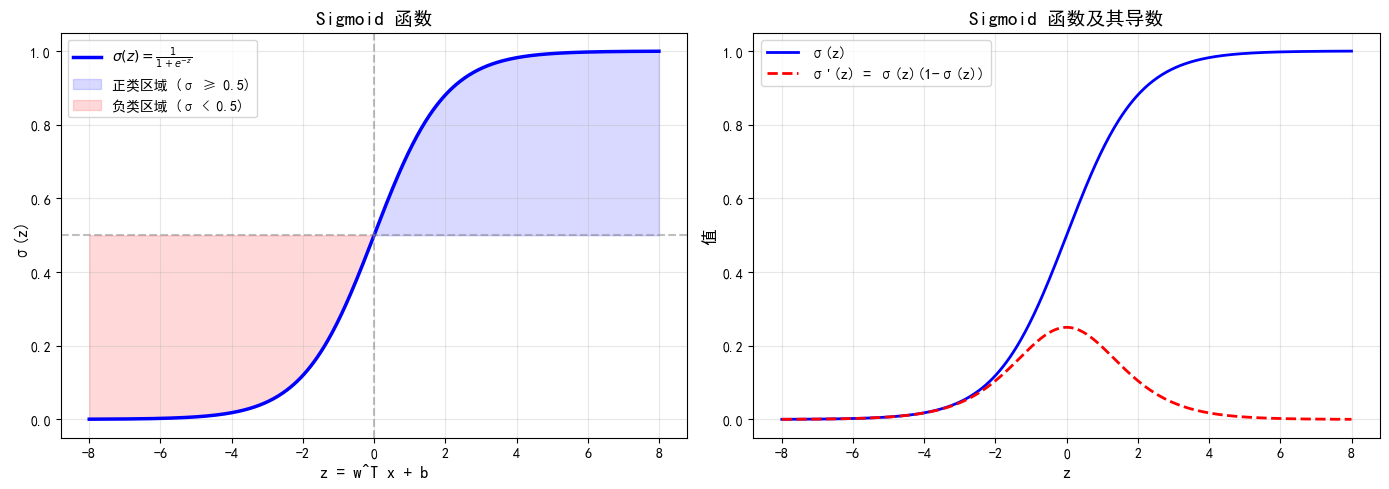

Sigmoid 函数将线性输出 z 映射为概率值 (0, 1)
当 z = 0 时, σ(z) = 0.5（决策边界）


In [8]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ========================
# Sigmoid 函数可视化
# ========================
z = np.linspace(-8, 8, 500)
sigmoid = 1 / (1 + np.exp(-z))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sigmoid 函数
ax1 = axes[0]
ax1.plot(z, sigmoid, 'b-', linewidth=2.5, label=r'$\sigma(z) = \frac{1}{1+e^{-z}}$')
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax1.fill_between(z, 0.5, sigmoid, where=(sigmoid >= 0.5), alpha=0.15, color='blue', label='正类区域 (σ ≥ 0.5)')
ax1.fill_between(z, sigmoid, 0.5, where=(sigmoid < 0.5), alpha=0.15, color='red', label='负类区域 (σ < 0.5)')
ax1.set_xlabel('z = w^T x + b', fontsize=12)
ax1.set_ylabel('σ(z)', fontsize=12)
ax1.set_title('Sigmoid 函数', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.05, 1.05)

# Sigmoid 导数
ax2 = axes[1]
sigmoid_grad = sigmoid * (1 - sigmoid)
ax2.plot(z, sigmoid, 'b-', linewidth=2, label='σ(z)')
ax2.plot(z, sigmoid_grad, 'r--', linewidth=2, label="σ'(z) = σ(z)(1-σ(z))")
ax2.set_xlabel('z', fontsize=12)
ax2.set_ylabel('值', fontsize=12)
ax2.set_title('Sigmoid 函数及其导数', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Sigmoid 函数将线性输出 z 映射为概率值 (0, 1)")
print("当 z = 0 时, σ(z) = 0.5（决策边界）")

---

## 2. 逻辑回归的决策边界

### 决策规则

给定输入 $\mathbf{x}$，逻辑回归输出概率 $P(y=1 | \mathbf{x}) = h(\mathbf{x})$：

$$\hat{y} = \begin{cases} 1, & \text{if } h(\mathbf{x}) \geq 0.5 \\ 0, & \text{if } h(\mathbf{x}) < 0.5 \end{cases}$$

等价于：

$$\hat{y} = \begin{cases} 1, & \text{if } \mathbf{w}^T \mathbf{x} + b \geq 0 \\ 0, & \text{if } \mathbf{w}^T \mathbf{x} + b < 0 \end{cases}$$

### 决策边界的含义

**决策边界**就是 $\mathbf{w}^T \mathbf{x} + b = 0$ 这条超平面：
- 在二维特征空间中，它是一条**直线**
- 在三维中，它是一个**平面**
- 在更高维中，它是超平面

$$w_1 x_1 + w_2 x_2 + b = 0 \implies x_2 = -\frac{w_1}{w_2}x_1 - \frac{b}{w_2}$$

### 非线性决策边界

通过多项式特征变换，逻辑回归也可以学习**非线性决策边界**：

$$h(\mathbf{x}) = \sigma(w_1 x_1^2 + w_2 x_2^2 + b)$$

可以得到**圆形**决策边界！

---

## 3. 交叉熵损失函数推导

### 为什么不用MSE？

如果对分类问题使用MSE：
$$J = \frac{1}{m}\sum_{i=1}^{m}(h(x^{(i)}) - y^{(i)})^2$$

MSE配合Sigmoid函数构成**非凸函数**，存在大量局部最小值，梯度下降难以找到全局最优解！

### 交叉熵损失（Binary Cross-Entropy）

从**最大似然估计（MLE）** 出发：

对于二分类问题，假设样本独立同分布，似然函数为：

$$L(\mathbf{w}, b) = \prod_{i=1}^{m} h(x^{(i)})^{y^{(i)}} (1 - h(x^{(i)}))^{1-y^{(i)}}$$

取对数得对数似然：

$$\ell(\mathbf{w}, b) = \sum_{i=1}^{m} \left[ y^{(i)} \ln h(x^{(i)}) + (1 - y^{(i)}) \ln(1 - h(x^{(i)})) \right]$$

最大化对数似然 = 最小化负对数似然（即交叉熵损失）：

$$J(\mathbf{w}, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \ln h(x^{(i)}) + (1 - y^{(i)}) \ln(1 - h(x^{(i)})) \right]$$

### 交叉熵损失的直觉

当 $y^{(i)} = 1$ 时：$J = -\ln h(x^{(i)})$，预测越接近1损失越小
当 $y^{(i)} = 0$ 时：$J = -\ln(1 - h(x^{(i)}))$，预测越接近0损失越小

### 统一公式

利用 $y^{(i)} \in \{0, 1\}$，可以将交叉熵写成统一形式：

$$J = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \ln(h^{(i)}) + (1-y^{(i)})\ln(1-h^{(i)}) \right]$$

> ⚠️ 注意：$h^{(i)} \in (0,1)$，需要避免 $\ln(0)$ 的数值问题（通常加一个极小值 $\epsilon$ clip）。

### 为什么交叉熵是凸函数？

交叉熵损失关于 $\mathbf{w}$ 是**凸函数**（可以证明Hessian矩阵半正定），因此梯度下降一定能找到全局最优解！这是选择交叉熵而非MSE的关键原因。

---

## 4. 梯度下降训练逻辑回归

### 梯度推导

对 $w_j$ 求偏导（利用 $\sigma'(z) = \sigma(z)(1-\sigma(z))$）：

$$\frac{\partial J}{\partial w_j} = \frac{1}{m} \sum_{i=1}^{m} (h^{(i)} - y^{(i)}) \cdot x_j^{(i)}$$

对 $b$ 求偏导：

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (h^{(i)} - y^{(i)})$$

> 💡 注意：梯度的形式与线性回归**完全一致**！只是 $h^{(i)}$ 的计算方式不同（Sigmoid vs 线性）。

### 向量化形式

$$\nabla_{\mathbf{w}} J = \frac{1}{m} X^T(H - \mathbf{y})$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \mathbf{1}^T(H - \mathbf{y})$$

### 参数更新规则

$$\mathbf{w} := \mathbf{w} - \alpha \cdot \nabla_{\mathbf{w}} J$$
$$b := b - \alpha \cdot \frac{\partial J}{\partial b}$$

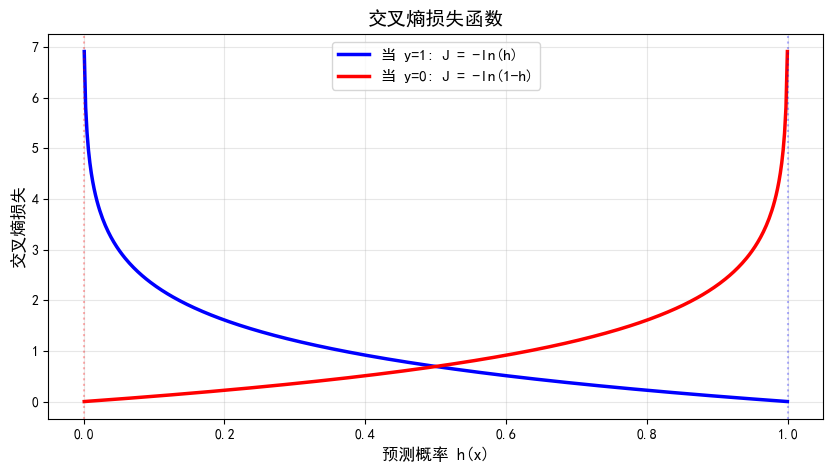

当 y=1 且预测 h→1 时，损失→0（正确预测惩罚小）
当 y=1 且预测 h→0 时，损失→∞（错误预测惩罚大）


In [9]:
# ========================
# 交叉熵损失可视化
# ========================
h = np.linspace(0.001, 0.999, 500)

loss_y1 = -np.log(h)        # 当 y=1 时的损失
loss_y0 = -np.log(1 - h)    # 当 y=0 时的损失

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(h, loss_y1, 'b-', linewidth=2.5, label='当 y=1: J = -ln(h)')
ax.plot(h, loss_y0, 'r-', linewidth=2.5, label='当 y=0: J = -ln(1-h)')
ax.axvline(x=1, color='b', linestyle=':', alpha=0.3)
ax.axvline(x=0, color='r', linestyle=':', alpha=0.3)
ax.set_xlabel('预测概率 h(x)', fontsize=12)
ax.set_ylabel('交叉熵损失', fontsize=12)
ax.set_title('交叉熵损失函数', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.05, 1.05)
plt.show()

print("当 y=1 且预测 h→1 时，损失→0（正确预测惩罚小）")
print("当 y=1 且预测 h→0 时，损失→∞（错误预测惩罚大）")

---

## 5. 🧪 从零实现逻辑回归（NumPy）

In [10]:
import numpy as np

class LogisticRegressionFromScratch:
    """
    从零实现的逻辑回归（梯度下降法）
    
    参数:
        learning_rate : float, 学习率 (默认 0.01)
        n_iterations  : int, 最大迭代次数 (默认 1000)
        tolerance     : float, 收敛阈值 (默认 1e-7)
        verbose        : bool, 是否打印训练信息
    """
    
    def __init__(self, learning_rate=0.01, n_iterations=1000, tolerance=1e-7, verbose=False):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.tolerance = tolerance
        self.verbose = verbose
        self.weights = None
        self.bias = None
        self.loss_history = []
    
    @staticmethod
    def _sigmoid(z):
        """Sigmoid 函数，带数值稳定处理"""
        return np.where(z >= 0,
                        1 / (1 + np.exp(-z)),
                        np.exp(z) / (1 + np.exp(z)))
    
    def _compute_loss(self, h, y):
        """计算二元交叉熵损失"""
        eps = 1e-15  # 避免数值溢出
        h = np.clip(h, eps, 1 - eps)
        return -np.mean(y * np.log(h) + (1 - y) * np.log(1 - h))
    
    def fit(self, X, y):
        """
        训练模型（批量梯度下降）
        
        参数:
            X : ndarray, shape (m, n), 训练特征矩阵
            y : ndarray, shape (m,), 训练标签 (0 或 1)
        """
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0.0
        self.loss_history = []
        
        for iteration in range(self.n_iterations):
            # 前向传播
            z = X @ self.weights + self.bias
            h = self._sigmoid(z)
            
            # 计算损失
            loss = self._compute_loss(h, y)
            self.loss_history.append(loss)
            
            # 计算梯度
            error = h - y
            dw = (1 / m) * X.T @ error
            db = (1 / m) * np.sum(error)
            
            # 更新参数
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # 收敛检查
            if iteration > 0 and abs(self.loss_history[-2] - loss) < self.tolerance:
                if self.verbose:
                    print(f"  在第 {iteration} 次迭代收敛！Loss = {loss:.8f}")
                break
        
        if self.verbose:
            print(f"  训练完成！共 {len(self.loss_history)} 次迭代, 最终Loss = {loss:.8f}")
        
        return self
    
    def predict_proba(self, X):
        """预测概率"""
        z = X @ self.weights + self.bias
        return self._sigmoid(z)
    
    def predict(self, X, threshold=0.5):
        """预测类别"""
        return (self.predict_proba(X) >= threshold).astype(int)
    
    def score(self, X, y):
        """计算准确率"""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

print("✅ LogisticRegressionFromScratch 类定义完成！")

✅ LogisticRegressionFromScratch 类定义完成！


In [11]:
# ========================
# 训练 & 评估
# ========================
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 生成二分类数据
np.random.seed(42)
X_cls, y_cls = make_classification(
    n_samples=500, n_features=2, n_redundant=0,
    n_informative=2, n_clusters_per_class=1, class_sep=2.0,
    random_state=42
)

# 划分训练/测试集
X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

# 特征标准化
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# --- 从零实现训练 ---
print("【从零实现】逻辑回归训练：")
model_lr_scratch = LogisticRegressionFromScratch(
    learning_rate=0.1, n_iterations=1000, verbose=True
)
model_lr_scratch.fit(X_train_s, y_train)

train_acc = model_lr_scratch.score(X_train_s, y_train)
test_acc = model_lr_scratch.score(X_test_s, y_test)
print(f"\n  训练集准确率 = {train_acc:.4f}")
print(f"  测试集准确率 = {test_acc:.4f}")
print(f"  学到的权重 = {model_lr_scratch.weights}")
print(f"  学到的偏置 = {model_lr_scratch.bias:.4f}")

【从零实现】逻辑回归训练：
  训练完成！共 1000 次迭代, 最终Loss = 0.07720316

  训练集准确率 = 0.9875
  测试集准确率 = 0.9600
  学到的权重 = [0.55620176 4.82604222]
  学到的偏置 = -0.2221


In [12]:
# ========================
# Scikit-learn LogisticRegression 对比
# ========================
from sklearn.linear_model import LogisticRegression as SKLogisticRegression

print("【Scikit-learn】逻辑回归训练：")
model_sk_lr = SKLogisticRegression(max_iter=1000, random_state=42)
model_sk_lr.fit(X_train_s, y_train)

sk_train_acc = model_sk_lr.score(X_train_s, y_train)
sk_test_acc = model_sk_lr.score(X_test_s, y_test)
print(f"\n  训练集准确率 = {sk_train_acc:.4f}")
print(f"  测试集准确率 = {sk_test_acc:.4f}")
print(f"  学到的权重 = {model_sk_lr.coef_[0]}")
print(f"  学到的偏置 = {model_sk_lr.intercept_[0]:.4f}")

# --- 对比 ---
print("\n" + "=" * 55)
print("           从零实现    vs    Scikit-learn")
print("=" * 55)
print(f"  训练准确率:  {train_acc:.4f}    vs    {sk_train_acc:.4f}")
print(f"  测试准确率:  {test_acc:.4f}    vs    {sk_test_acc:.4f}")
print("=" * 55)
print("✅ 两种方法准确率非常接近！")

【Scikit-learn】逻辑回归训练：

  训练集准确率 = 0.9875
  测试集准确率 = 0.9600
  学到的权重 = [0.55764129 4.95812645]
  学到的偏置 = -0.2700

           从零实现    vs    Scikit-learn
  训练准确率:  0.9875    vs    0.9875
  测试准确率:  0.9600    vs    0.9600
✅ 两种方法准确率非常接近！


---

## 7. 🔬 可视化决策边界

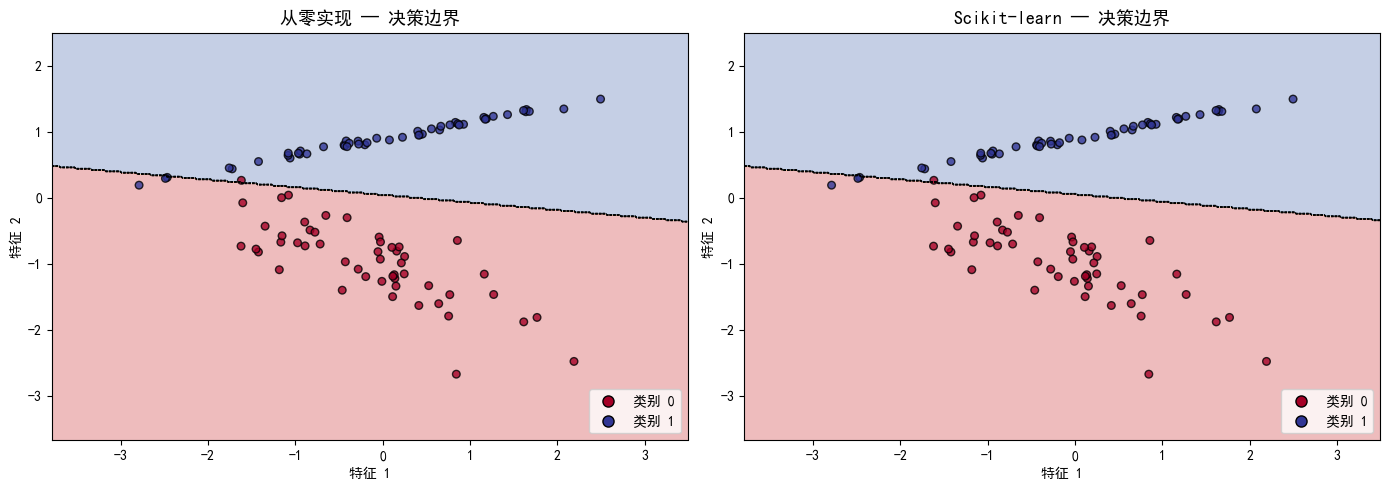

In [13]:
# ========================
# 可视化1: 决策边界
# ========================

def plot_decision_boundary(model, X, y, ax, title="决策边界"):
    """绘制二维决策边界"""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    ax.contour(xx, yy, Z, colors='k', linewidths=0.5, linestyles='--')
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, 
                         edgecolors='k', s=30, alpha=0.8)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('特征 1')
    ax.set_ylabel('特征 2')
    # 添加图例，对类别进行区分
    classes = np.unique(y)
    handles = []
    labels = []
    for cls in classes:
        handles.append(
            plt.Line2D(
                [], [],
                marker='o',
                color='w',
                markerfacecolor=plt.cm.RdYlBu(cls / (len(classes) - 1)),
                markeredgecolor='k',
                markersize=8,
                linestyle='None'
            )
        )
        labels.append(f'类别 {cls}')
    ax.legend(handles, labels, loc='lower right')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 从零实现的决策边界
plot_decision_boundary(model_lr_scratch, X_test_s, y_test, axes[0],
                      title='从零实现 — 决策边界')

# sklearn 的决策边界
plot_decision_boundary(model_sk_lr, X_test_s, y_test, axes[1],
                      title='Scikit-learn — 决策边界')

plt.tight_layout()
plt.show()

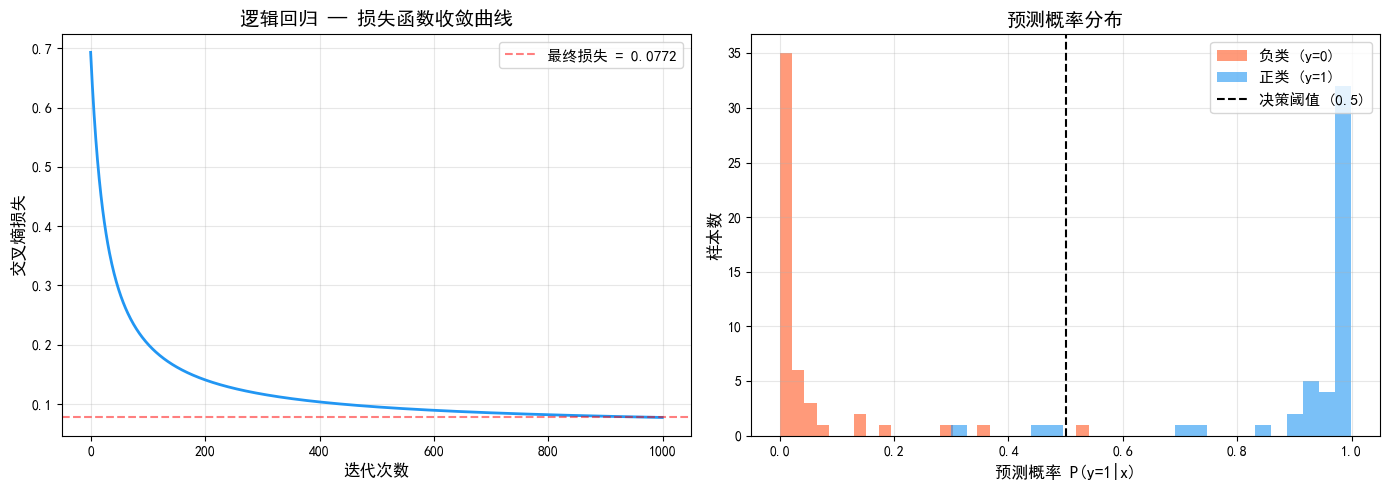

理想情况下，正类概率集中在1附近，负类概率集中在0附近。


In [14]:
# ========================
# 可视化2: 损失函数下降曲线 + 概率分布
# ========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 损失下降曲线
ax1 = axes[0]
ax1.plot(model_lr_scratch.loss_history, linewidth=2, color='#2196F3')
ax1.set_xlabel('迭代次数', fontsize=12)
ax1.set_ylabel('交叉熵损失', fontsize=12)
ax1.set_title('逻辑回归 — 损失函数收敛曲线', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=model_lr_scratch.loss_history[-1], color='r', linestyle='--', alpha=0.5,
            label=f'最终损失 = {model_lr_scratch.loss_history[-1]:.4f}')
ax1.legend(fontsize=11)

# 预测概率分布
ax2 = axes[1]
y_proba = model_lr_scratch.predict_proba(X_test_s)
ax2.hist(y_proba[y_test == 0], bins=25, alpha=0.6, label='负类 (y=0)', color='#FF5722')
ax2.hist(y_proba[y_test == 1], bins=25, alpha=0.6, label='正类 (y=1)', color='#2196F3')
ax2.axvline(x=0.5, color='k', linestyle='--', linewidth=1.5, label='决策阈值 (0.5)')
ax2.set_xlabel('预测概率 P(y=1|x)', fontsize=12)
ax2.set_ylabel('样本数', fontsize=12)
ax2.set_title('预测概率分布', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("理想情况下，正类概率集中在1附近，负类概率集中在0附近。")

原始特征维度: 2
多项式特征维度: 5
  训练完成！共 2000 次迭代, 最终Loss = 0.14313491

准确率 = 0.9400


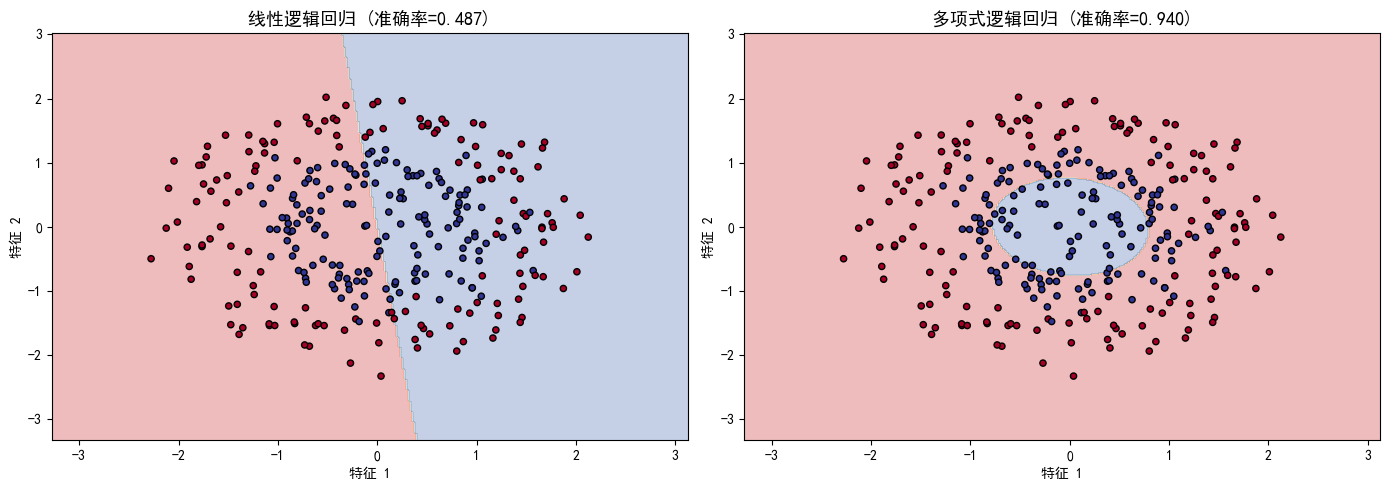


✅ 多项式特征可以将线性决策边界扩展为非线性决策边界！


In [15]:
# ========================
# 可视化3: 非线性决策边界（通过多项式特征）
# ========================
from sklearn.datasets import make_circles
from sklearn.preprocessing import PolynomialFeatures

# 生成同心圆数据
X_circle, y_circle = make_circles(n_samples=300, noise=0.15, factor=0.5, random_state=42)

scaler_c = StandardScaler()
X_circle_s = scaler_c.fit_transform(X_circle)

# 多项式特征变换（二次）
poly = PolynomialFeatures(degree=2, include_bias=False)
X_circle_poly = poly.fit_transform(X_circle_s)
print(f"原始特征维度: {X_circle_s.shape[1]}")
print(f"多项式特征维度: {X_circle_poly.shape[1]}")

# 训练逻辑回归
model_circle = LogisticRegressionFromScratch(learning_rate=0.5, n_iterations=2000, verbose=True)
model_circle.fit(X_circle_poly, y_circle)
acc_circle = model_circle.score(X_circle_poly, y_circle)
print(f"\n准确率 = {acc_circle:.4f}")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 线性逻辑回归（原始特征）
model_lin = LogisticRegressionFromScratch(learning_rate=0.1, n_iterations=1000)
model_lin.fit(X_circle_s, y_circle)
acc_lin = model_lin.score(X_circle_s, y_circle)

ax1 = axes[0]
h = 0.02
x_min, x_max = X_circle_s[:, 0].min()-1, X_circle_s[:, 0].max()+1
y_min, y_max = X_circle_s[:, 1].min()-1, X_circle_s[:, 1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z1 = model_lin.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax1.contourf(xx, yy, Z1, alpha=0.3, cmap=plt.cm.RdYlBu)
ax1.scatter(X_circle_s[:, 0], X_circle_s[:, 1], c=y_circle, cmap=plt.cm.RdYlBu, edgecolors='k', s=20)
ax1.set_title(f'线性逻辑回归 (准确率={acc_lin:.3f})', fontsize=13)
ax1.set_xlabel('特征 1'); ax1.set_ylabel('特征 2')

# 多项式逻辑回归
ax2 = axes[1]
X_grid = np.c_[xx.ravel(), yy.ravel()]
X_grid_s = scaler_c.transform(X_grid)
X_grid_poly = poly.transform(X_grid_s)
Z2 = model_circle.predict(X_grid_poly).reshape(xx.shape)
ax2.contourf(xx, yy, Z2, alpha=0.3, cmap=plt.cm.RdYlBu)
ax2.scatter(X_circle_s[:, 0], X_circle_s[:, 1], c=y_circle, cmap=plt.cm.RdYlBu, edgecolors='k', s=20)
ax2.set_title(f'多项式逻辑回归 (准确率={acc_circle:.3f})', fontsize=13)
ax2.set_xlabel('特征 1'); ax2.set_ylabel('特征 2')

plt.tight_layout()
plt.show()

print("\n✅ 多项式特征可以将线性决策边界扩展为非线性决策边界！")

---

## 8. 💡 练习题

### 练习1：手动推导梯度（基础）

请手动推导逻辑回归的梯度公式：

已知 $J = -\frac{1}{m}\sum[y \ln h + (1-y)\ln(1-h)]$，其中 $h = \sigma(z) = \sigma(\mathbf{w}^T\mathbf{x}+b)$。

证明：$\frac{\partial J}{\partial w_j} = \frac{1}{m}\sum_{i=1}^{m}(h^{(i)} - y^{(i)})x_j^{(i)}$

> **提示**：利用 $\sigma'(z) = \sigma(z)(1-\sigma(z))$ 和链式法则。

### 练习2：阈值调整实验

将决策阈值从0.5调整为0.3和0.7，观察对以下指标的影响：
- 准确率（Accuracy）
- 精确率（Precision）
- 召回率（Recall）

讨论在什么场景下应该提高/降低阈值。

### 练习3：多分类逻辑回归

使用 `make_classification(n_classes=3, ...)` 生成多分类数据，尝试：
- One-vs-Rest 策略：训练3个二分类逻辑回归
- 与 Scikit-learn 的 `LogisticRegression(multi_class='ovr')` 和 `multi_class='multinomial'` 对比

### 练习4：手写数字识别（选做）

使用 Scikit-learn 的 `load_digits` 数据集，训练逻辑回归模型进行手写数字（0-9）识别，计算混淆矩阵。

---

> 📌 **本节要点回顾**：
> - Sigmoid函数将线性输出映射为概率，是逻辑回归的核心
> - 交叉熵损失是凸函数，适合用于分类优化（MSE则不是）
> - 逻辑回归的梯度形式与线性回归一致，只是 $h(x)$ 不同
> - 决策边界是 $\mathbf{w}^T\mathbf{x}+b=0$ 超平面
> - 通过多项式特征可以实现非线性决策边界